In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


#Upload and Read the Dataset

In [7]:
import zipfile
with zipfile.ZipFile("/content/Walmart.zip", 'r') as zip_ref:
    zip_ref.extractall("/content")

df = pd.read_csv("/content/Walmart DataSet.csv")
print(df.head())
print(df.info())

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   i

#Basic Exploration & Cleaning

In [10]:

print(df.isnull().sum())

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print(df.describe())

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64
             Store                 Date  Weekly_Sales  Holiday_Flag  \
count  6435.000000                 6435  6.435000e+03   6435.000000   
mean     23.000000  2011-06-17 00:00:00  1.046965e+06      0.069930   
min       1.000000  2010-02-05 00:00:00  2.099862e+05      0.000000   
25%      12.000000  2010-10-08 00:00:00  5.533501e+05      0.000000   
50%      23.000000  2011-06-17 00:00:00  9.607460e+05      0.000000   
75%      34.000000  2012-02-24 00:00:00  1.420159e+06      0.000000   
max      45.000000  2012-10-26 00:00:00  3.818686e+06      1.000000   
std      12.988182                  NaN  5.643666e+05      0.255049   

       Temperature   Fuel_Price          CPI  Unemployment  
count  6435.000000  6435.000000  6435.000000   6435.000000  
mean     60.663782     3.358607   171.578394      7.999151  
min      -2.060000  

#Exploratory Data Analysis (EDA)

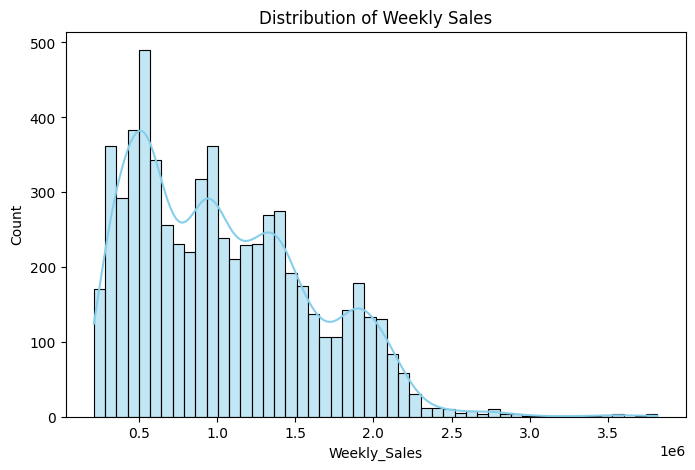

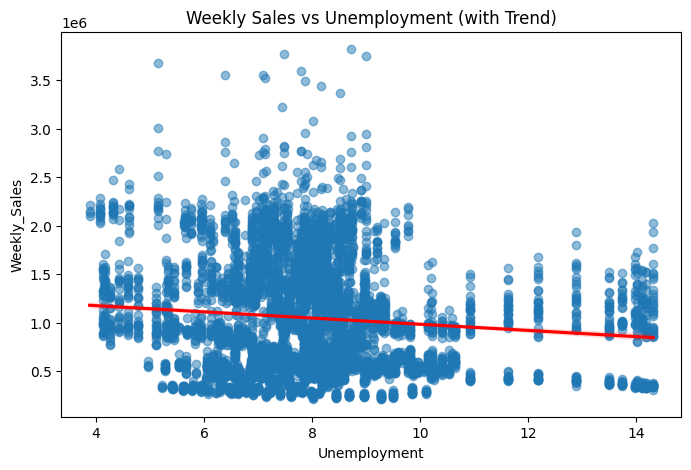

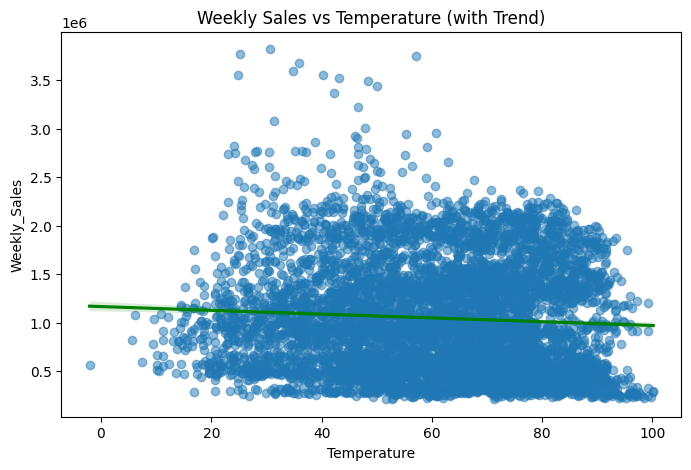

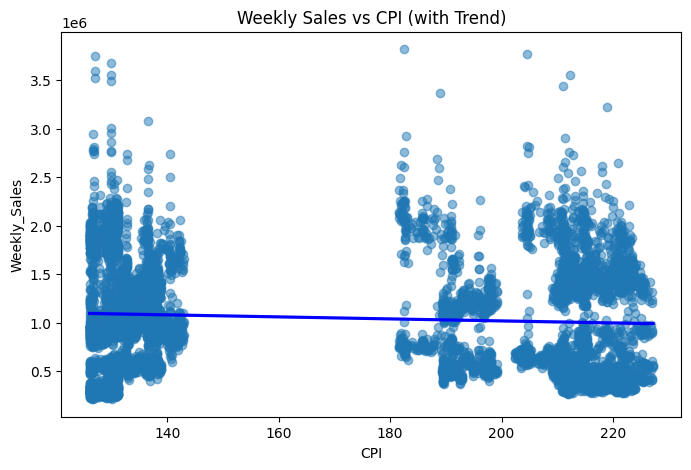

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Weekly sales distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Weekly_Sales'], bins=50, kde=True, color="skyblue")
plt.title("Distribution of Weekly Sales")
plt.show()

# Sales vs Unemployment
plt.figure(figsize=(8,5))
sns.regplot(x='Unemployment', y='Weekly_Sales', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Weekly Sales vs Unemployment (with Trend)")
plt.show()

# Sales vs Temperature
plt.figure(figsize=(8,5))
sns.regplot(x='Temperature', y='Weekly_Sales', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'green'})
plt.title("Weekly Sales vs Temperature (with Trend)")
plt.show()

# Sales vs CPI
plt.figure(figsize=(8,5))
sns.regplot(x='CPI', y='Weekly_Sales', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'blue'})
plt.title("Weekly Sales vs CPI (with Trend)")
plt.show()


#Seasonal Trend Analysis

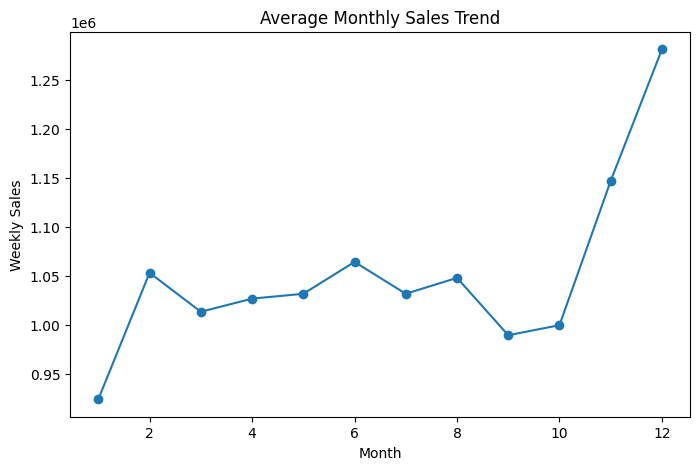

In [13]:
# Add Year and Month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Group by Month
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()

plt.figure(figsize=(8,5))
monthly_sales.plot(kind='line', marker='o')
plt.title("Average Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Weekly Sales")
plt.show()


#Top & Worst Performing Stores

Top 5 Performing Stores:
 Store
20    2.107677e+06
4     2.094713e+06
14    2.020978e+06
13    2.003620e+06
2     1.925751e+06
Name: Weekly_Sales, dtype: float64
Worst Performing Store:
 Store
33    259861.692028
Name: Weekly_Sales, dtype: float64


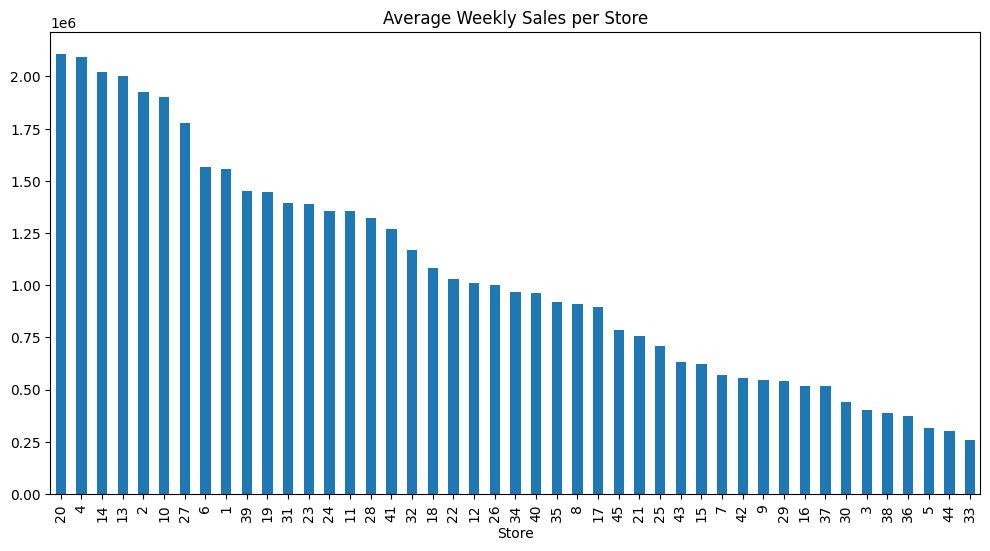

In [14]:
store_sales = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)

print("Top 5 Performing Stores:\n", store_sales.head())
print("Worst Performing Store:\n", store_sales.tail(1))

plt.figure(figsize=(12,6))
store_sales.plot(kind='bar')
plt.title("Average Weekly Sales per Store")
plt.show()


#Outlier Analysis

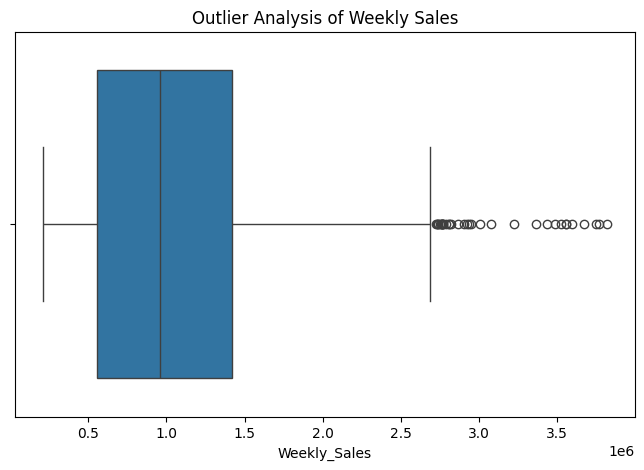

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Weekly_Sales', data=df)
plt.title("Outlier Analysis of Weekly Sales")
plt.show()


#Predictive Modeling (Forecasting Next 12 Weeks)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:989: EstimationWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  params_variance) = self._conditional_sum_squares(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


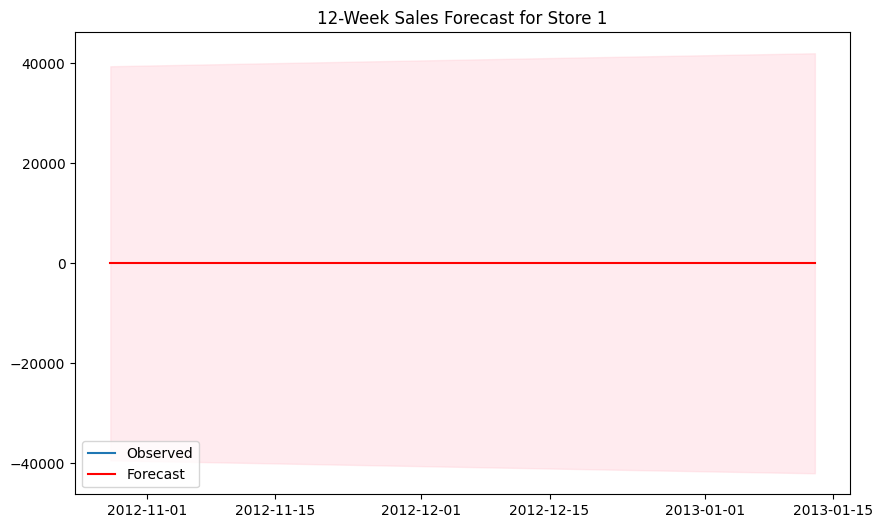

In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Forecast for Store 1
store1 = df[df['Store']==1].set_index('Date')
store1_sales = store1['Weekly_Sales'].asfreq('W')

# Fit ARIMA model
model = SARIMAX(store1_sales, order=(1,1,1), seasonal_order=(1,1,1,52))
results = model.fit()

# Forecast next 12 weeks
forecast = results.get_forecast(steps=12)
forecast_ci = forecast.conf_int()

plt.figure(figsize=(10,6))
plt.plot(store1_sales.index, store1_sales, label='Observed')
plt.plot(forecast.predicted_mean.index, forecast.predicted_mean, label='Forecast', color='red')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1], color='pink', alpha=0.3)
plt.title("12-Week Sales Forecast for Store 1")
plt.legend()
plt.show()